# AI-Based 5G Network Congestion Prediction and Load Balancing System

This notebook implements a clean neural-network-only pipeline for 5G congestion prediction and network optimization. The model and the decision engine now share one feature list so the full system stays stable, reproducible, and free from hidden column dependencies.

### 1. Import Libraries

This section imports the preprocessing, neural-network, evaluation, and plotting libraries used throughout the notebook. GPU support is retained so the same pipeline can run on CUDA when available and on CPU otherwise.

In [242]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 2. Load Dataset

The raw 5G telemetry dataset is loaded from the project directory. All engineered features are created inside the notebook so the full pipeline stays reproducible from the original CSV.

In [243]:
df = pd.read_csv("5g_network_data_processed.csv")
df.head()

,Location,Signal_Strength_dBm,Download_Speed_Mbps,Upload_Speed_Mbps,Latency_ms,Jitter_ms,Network_Type,Device_Model,Carrier,Band,...,Video_Streaming_Quality,VoNR_Enabled,Network_Congestion_Level,Ping_to_Google_ms,Dropped_Connection,Speed_Ratio,Latency_Jitter,Signal_Latency,Load_Index,Stress_Score
0,San Francisco,-108.6,714.94,60.41,10.0,4.09,5G NSA,iPhone 14,AT&T,n78,...,4,False,Medium,27.9,True,11.834795,40.900,-9.872727,6.493333,0.528925
1,San Francisco,-71.5,686.69,148.70,12.3,1.50,4G,Pixel 7,AT&T,n260,...,3,True,Low,22.2,False,4.617956,18.450,-5.375940,2.754423,0.318890
2,Chennai,-67.5,796.34,136.33,19.9,1.22,5G NSA,iPhone 14,Airtel,n78,...,5,False,Medium,75.5,False,5.841267,24.278,-3.229665,3.894565,0.448523
3,New York,-73.3,208.56,68.59,12.2,4.94,4G,Pixel 7,T-Mobile,n41,...,4,False,Medium,87.5,False,3.040676,60.268,-5.553030,2.630000,0.646641
4,Kolkata,-93.2,409.85,137.23,6.3,2.94,5G NSA,Galaxy S23,BSNL,n28,...,1,True,Medium,32.5,True,2.986592,18.522,-12.767123,2.852909,0.439001


### 3. Data Cleaning and Feature Engineering

This section standardizes column names, converts boolean flags to integers, drops the raw timestamp, and creates engineered features that capture throughput balance, latency instability, radio-delay coupling, and traffic load. A single feature list is then used as the source of truth for both the model and the decision engine.

In [244]:
df.columns = (
    df.columns.str.strip()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

if "VoNR_Enabled" in df.columns:
    df["VoNR_Enabled"] = df["VoNR_Enabled"].astype(int)
if "Dropped_Connection" in df.columns:
    df["Dropped_Connection"] = df["Dropped_Connection"].astype(int)

df = df.drop(columns=["Timestamp"], errors="ignore")

df["Speed_Ratio"] = df["Download_Speed_Mbps"] / (df["Upload_Speed_Mbps"] + 1e-6)
df["Latency_Jitter"] = df["Latency_ms"] * df["Jitter_ms"]
df["Signal_Latency"] = df["Signal_Strength_dBm"] / (df["Latency_ms"] + 1)
df["Load_Index"] = df["Data_Usage_MB"] / (df["Connected_Duration_min"] + 1)

features = [
    "Signal_Strength_dBm",
    "Download_Speed_Mbps",
    "Upload_Speed_Mbps",
    "Latency_ms",
    "Jitter_ms",
    "Ping_to_Google_ms",
    "Data_Usage_MB",
    "Handover_Count",
    "Connected_Duration_min",
    "Speed_Ratio",
    "Latency_Jitter",
    "Signal_Latency",
    "Load_Index"
]

missing_features = []
for col in features:
    if col not in df.columns:
        print("Missing column:", col)
        missing_features.append(col)

if missing_features:
    raise KeyError(f"Missing required features: {missing_features}")

X_original = df[features].copy()
y = df["Network_Congestion_Level"].map({"Low": 0, "Medium": 1, "High": 2})
label_names = {0: "Low", 1: "Medium", 2: "High"}

if y.isna().any():
    raise ValueError("Unexpected labels found in Network_Congestion_Level.")

print("Features used across the system:", features)
print(df[features].head())

Features used across the system: ['Signal_Strength_dBm', 'Download_Speed_Mbps', 'Upload_Speed_Mbps', 'Latency_ms', 'Jitter_ms', 'Ping_to_Google_ms', 'Data_Usage_MB', 'Handover_Count', 'Connected_Duration_min', 'Speed_Ratio', 'Latency_Jitter', 'Signal_Latency', 'Load_Index']
   Signal_Strength_dBm  Download_Speed_Mbps  Upload_Speed_Mbps  Latency_ms  \
0               -108.6               714.94              60.41        10.0   
1                -71.5               686.69             148.70        12.3   
2                -67.5               796.34             136.33        19.9   
3                -73.3               208.56              68.59        12.2   
4                -93.2               409.85             137.23         6.3   

   Jitter_ms  Ping_to_Google_ms  Data_Usage_MB  Handover_Count  \
0       4.09               27.9          97.40               1   
1       1.50               22.2         143.23               4   
2       1.22               75.5         179.15            

### 4. Train/Test Split and Scaling

The system uses a fixed ordered 90/10 split to preserve row order. Min-max scaling is fit on training data only so the test window does not leak information into preprocessing statistics.

In [245]:
split_index = int(len(X_original) * 0.8)

X_train_original = X_original.iloc[:split_index].reset_index(drop=True)
X_test_original = X_original.iloc[split_index:].reset_index(drop=True)
y_train_series = y.iloc[:split_index].copy()
y_test_series = y.iloc[split_index:].copy()

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_original)
X_test = scaler.transform(X_test_original)

classes = np.array(sorted(y_train_series.unique()))
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_series
)
class_weights = torch.tensor(class_weight_values, dtype=torch.float32, device=device)

X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
X_test = torch.tensor(X_test, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train_series.values, dtype=torch.long, device=device)
y_test = torch.tensor(y_test_series.values, dtype=torch.long, device=device)

print(f"Train samples: {len(X_train_original)}, Test samples: {len(X_test_original)}")
print("Class weights:", dict(zip(classes.tolist(), class_weight_values.tolist())))

Train samples: 40000, Test samples: 10000
Class weights: {0: 1.801558347970995, 1: 0.4276245456489203, 2: 9.396288466055909}


### 5. TELU Neural Network

The model uses only the shared numeric feature list. TELU is kept as the activation function, the exponential term is clamped for stability, and BatchNorm plus Dropout improve optimization stability without changing the system feature space.

In [246]:
class TELU(nn.Module):
    def forward(self, x):
        clamped_x = torch.clamp(x, max=10.0)
        return x * torch.tanh(torch.exp(clamped_x))


class Net(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            TELU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            TELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            TELU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.net(x)


model = Net(X_train.shape[1]).to(device)

### 6. Training

The neural network is trained with AdamW and class-weighted cross-entropy loss. Train/test loss and accuracy are recorded every epoch so the learning dynamics can be inspected directly.

In [247]:


criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

train_loss_history = []
test_loss_history = []
train_accuracy_history = []
test_accuracy_history = []

for epoch in range(150):
    model.train()
    train_outputs = model(X_train)
    loss = criterion(train_outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        train_eval_outputs = model(X_train)
        test_eval_outputs = model(X_test)

        train_loss = criterion(train_eval_outputs, y_train).item()
        test_loss = criterion(test_eval_outputs, y_test).item()

        train_predictions = torch.argmax(train_eval_outputs, dim=1)
        test_predictions = torch.argmax(test_eval_outputs, dim=1)

        train_accuracy = (train_predictions == y_train).float().mean().item()
        test_accuracy = (test_predictions == y_test).float().mean().item()

    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)
    train_accuracy_history.append(train_accuracy)
    test_accuracy_history.append(test_accuracy)

    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1}/50, "
            f"Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, "
            f"Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}"
        )

torch.save(model.state_dict(), "model.pth")
print("Saved trained model to model.pth")

Epoch 1/50, Train Loss: 1.0954, Test Loss: 1.0973, Train Accuracy: 0.7795, Test Accuracy: 0.7781
Epoch 5/50, Train Loss: 1.0446, Test Loss: 1.0492, Train Accuracy: 0.7335, Test Accuracy: 0.7311
Epoch 10/50, Train Loss: 0.9305, Test Loss: 0.9401, Train Accuracy: 0.4915, Test Accuracy: 0.4929
Epoch 15/50, Train Loss: 0.7872, Test Loss: 0.8001, Train Accuracy: 0.5681, Test Accuracy: 0.5674
Epoch 20/50, Train Loss: 0.6597, Test Loss: 0.6719, Train Accuracy: 0.5486, Test Accuracy: 0.5564
Epoch 25/50, Train Loss: 0.5612, Test Loss: 0.5704, Train Accuracy: 0.5195, Test Accuracy: 0.5280
Epoch 30/50, Train Loss: 0.4922, Test Loss: 0.4993, Train Accuracy: 0.5199, Test Accuracy: 0.5240
Epoch 35/50, Train Loss: 0.4455, Test Loss: 0.4521, Train Accuracy: 0.5296, Test Accuracy: 0.5343
Epoch 40/50, Train Loss: 0.4110, Test Loss: 0.4175, Train Accuracy: 0.5604, Test Accuracy: 0.5669
Epoch 45/50, Train Loss: 0.3777, Test Loss: 0.3841, Train Accuracy: 0.6137, Test Accuracy: 0.6208
Epoch 50/50, Train Los

### 7. Evaluation

The final evaluation prints the neural-network accuracy, prediction distribution, classification report, and confusion matrix. The predictions and text metrics are also saved for later review.

In [248]:
model.eval()
with torch.no_grad():
    preds = model(X_test)
    predicted = torch.argmax(preds, dim=1)

y_test_np = y_test.cpu().numpy()
predicted_np = predicted.cpu().numpy()
final_train_accuracy = train_accuracy_history[-1]
nn_accuracy = (predicted == y_test).float().mean().item()
prediction_distribution = torch.bincount(predicted.cpu(), minlength=3)
cm = confusion_matrix(y_test_np, predicted_np, labels=[0, 1, 2])
classification_text = classification_report(
    y_test_np,
    predicted_np,
    labels=[0, 1, 2],
    target_names=["Low", "Medium", "High"],
    zero_division=0
)

print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"NN Accuracy (ordered 90/10): {nn_accuracy:.4f}")
print("Prediction distribution:", prediction_distribution)
print(classification_text)
print(cm)

results_df = pd.DataFrame({
    "actual_label": [label_names[label] for label in y_test_np],
    "predicted_label": [label_names[label] for label in predicted_np]
})
results_df.to_csv("test_results.csv", index=False)

with open("metrics.txt", "w", encoding="utf-8") as metrics_file:
    metrics_file.write(f"Final Training Accuracy: {final_train_accuracy:.4f}\n")
    metrics_file.write(f"NN Accuracy (ordered 90/10): {nn_accuracy:.4f}\n")
    metrics_file.write(f"Prediction distribution: {prediction_distribution.tolist()}\n\n")
    metrics_file.write("Features used:\n")
    metrics_file.write("\n".join(features))
    metrics_file.write("\n\nClassification Report:\n")
    metrics_file.write(classification_text)
    metrics_file.write("\nConfusion Matrix:\n")
    metrics_file.write(np.array2string(cm))

print("Saved test predictions to test_results.csv")
print("Saved evaluation metrics to metrics.txt")

Final Training Accuracy: 0.9207
NN Accuracy (ordered 90/10): 0.9222
Prediction distribution: tensor([2352, 7003,  645])
              precision    recall  f1-score   support

         Low       0.81      1.00      0.89      1897
      Medium       1.00      0.90      0.95      7781
        High       0.50      1.00      0.67       322

    accuracy                           0.92     10000
   macro avg       0.77      0.97      0.84     10000
weighted avg       0.95      0.92      0.93     10000

[[1897    0    0]
 [ 455 7003  323]
 [   0    0  322]]
Saved test predictions to test_results.csv
Saved evaluation metrics to metrics.txt


### 8. Decision Engine

The decision engine uses the same feature list as the neural network. Stress scoring is built from the training portion of the selected feature dataframe only, and safe dictionary-style access is used throughout the row logic to prevent KeyError crashes.

In [249]:
print("Columns used:", X_train_original.columns)
print("Test shape:", X_test_original.shape)

stress_features = [
    "Latency_ms",
    "Jitter_ms",
    "Ping_to_Google_ms",
    "Download_Speed_Mbps",
    "Upload_Speed_Mbps",
    "Signal_Strength_dBm",
    "Data_Usage_MB",
    "Handover_Count",
    "Load_Index"
]

for col in stress_features:
    if col not in X_train_original.columns:
        print("Missing column:", col)

stress_feature_ranges = {
    col: (X_train_original[col].min(), X_train_original[col].max())
    for col in stress_features
    if col in X_train_original.columns
}

def normalize_metric(value, min_val, max_val, invert=False):
    if max_val == min_val:
        return 0.0
    normalized = (value - min_val) / (max_val - min_val)
    normalized = float(np.clip(normalized, 0.0, 1.0))
    return 1.0 - normalized if invert else normalized

def compute_network_stress(row):
    return (
        0.18 * normalize_metric(row.get("Latency_ms", 0), *stress_feature_ranges["Latency_ms"]) +
        0.10 * normalize_metric(row.get("Jitter_ms", 0), *stress_feature_ranges["Jitter_ms"]) +
        0.12 * normalize_metric(row.get("Ping_to_Google_ms", 0), *stress_feature_ranges["Ping_to_Google_ms"]) +
        0.12 * normalize_metric(row.get("Download_Speed_Mbps", 0), *stress_feature_ranges["Download_Speed_Mbps"], True) +
        0.08 * normalize_metric(row.get("Upload_Speed_Mbps", 0), *stress_feature_ranges["Upload_Speed_Mbps"], True) +
        0.14 * normalize_metric(row.get("Signal_Strength_dBm", 0), *stress_feature_ranges["Signal_Strength_dBm"], True) +
        0.08 * normalize_metric(row.get("Data_Usage_MB", 0), *stress_feature_ranges["Data_Usage_MB"]) +
        0.05 * normalize_metric(row.get("Handover_Count", 0), *stress_feature_ranges["Handover_Count"]) +
        0.13 * normalize_metric(row.get("Load_Index", 0), *stress_feature_ranges["Load_Index"])
    )

def optimize_network(row, pred, stress):
    latency = row.get("Latency_ms", 0)
    jitter = row.get("Jitter_ms", 0)
    signal = row.get("Signal_Strength_dBm", 0)
    download = row.get("Download_Speed_Mbps", 0)
    handovers = row.get("Handover_Count", 0)
    load = row.get("Load_Index", 0)
    throughput_baseline = X_train_original["Download_Speed_Mbps"].median()

    if pred == 2:
        if latency > 15 and stress > 0.65:
            return "Route to low latency path"
        if signal < -95 and stress > 0.60:
            return "Switch to stronger cell"
        if jitter > 8 or handovers >= 6:
            return "Stabilize connection"
        return "Immediate load balancing"

    if pred == 1:
        if stress > 0.60 or load > X_train_original["Load_Index"].median():
            return "Immediate load balancing"
        if latency > 15:
            return "Route to low latency path"
        if signal < -95:
            return "Switch to stronger cell"
        if jitter > 8 or handovers >= 6:
            return "Stabilize connection"
        if stress > 0.45 or download < throughput_baseline:
            return "Monitor network"
        return "No action"

    if stress > 0.55:
        return "Monitor network"
    if jitter > 8 and signal < -95:
        return "Stabilize connection"
    return "No action"

stress_scores = []
actions = []

for i in range(len(predicted_np)):
    row = X_test_original.iloc[i]
    stress = compute_network_stress(row)
    stress_scores.append(stress)
    actions.append(optimize_network(row, predicted_np[i], stress))

action_counts = pd.Series(actions).value_counts()
decision_preview = pd.DataFrame({
    "Predicted_Congestion": [label_names[label] for label in predicted_np],
    "Stress_Score": np.round(stress_scores, 3),
    "Recommended_Action": actions
})

decision_preview.head(10)

Columns used: Index(['Signal_Strength_dBm', 'Download_Speed_Mbps', 'Upload_Speed_Mbps',
       'Latency_ms', 'Jitter_ms', 'Ping_to_Google_ms', 'Data_Usage_MB',
       'Handover_Count', 'Connected_Duration_min', 'Speed_Ratio',
       'Latency_Jitter', 'Signal_Latency', 'Load_Index'],
      dtype='object')
Test shape: (10000, 13)


,Predicted_Congestion,Stress_Score,Recommended_Action
0,Low,0.328,No action
1,Medium,0.513,Switch to stronger cell
2,Medium,0.436,Monitor network
3,Medium,0.457,Immediate load balancing
4,Medium,0.518,Immediate load balancing
5,Medium,0.495,Immediate load balancing
6,Low,0.306,No action
7,Medium,0.457,Immediate load balancing
8,Low,0.358,No action
9,Medium,0.543,Immediate load balancing


### 9. Visualization

The plots below summarize the neural-network learning curves, the prediction behavior, the confusion matrix, and the final decision-engine actions.

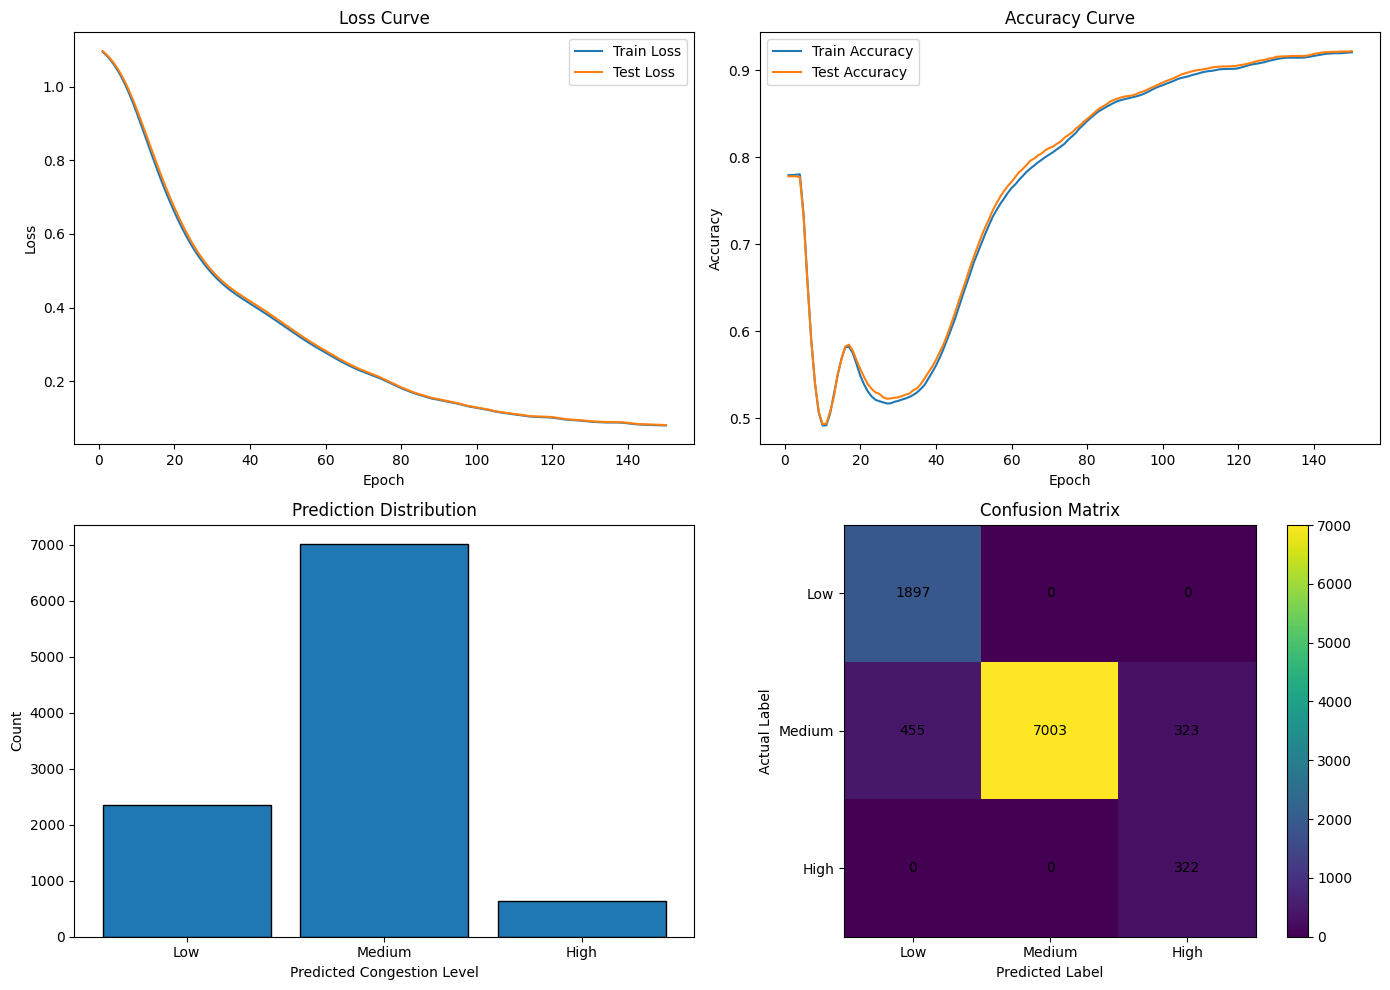

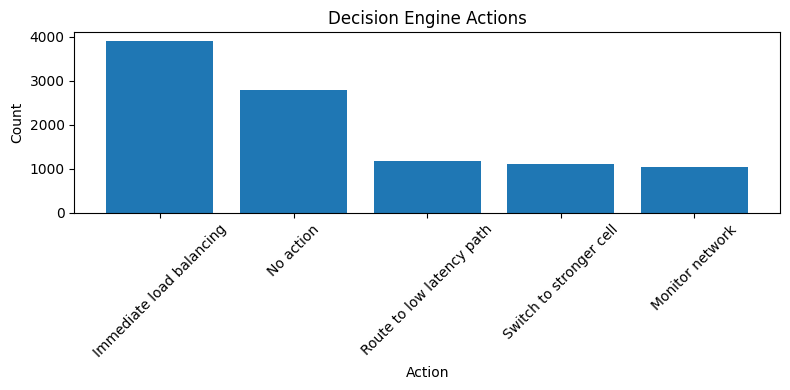

In [250]:
epochs = range(1, len(train_loss_history) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(epochs, train_loss_history, label="Train Loss")
axes[0, 0].plot(epochs, test_loss_history, label="Test Loss")
axes[0, 0].set_title("Loss Curve")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

axes[0, 1].plot(epochs, train_accuracy_history, label="Train Accuracy")
axes[0, 1].plot(epochs, test_accuracy_history, label="Test Accuracy")
axes[0, 1].set_title("Accuracy Curve")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()

axes[1, 0].hist(predicted_np, bins=np.arange(-0.5, 3.5, 1), edgecolor="black", rwidth=0.85)
axes[1, 0].set_xticks([0, 1, 2], ["Low", "Medium", "High"])
axes[1, 0].set_title("Prediction Distribution")
axes[1, 0].set_xlabel("Predicted Congestion Level")
axes[1, 0].set_ylabel("Count")

confusion_image = axes[1, 1].imshow(cm)
axes[1, 1].set_title("Confusion Matrix")
axes[1, 1].set_xlabel("Predicted Label")
axes[1, 1].set_ylabel("Actual Label")
axes[1, 1].set_xticks([0, 1, 2], ["Low", "Medium", "High"])
axes[1, 1].set_yticks([0, 1, 2], ["Low", "Medium", "High"])

for row_index in range(cm.shape[0]):
    for col_index in range(cm.shape[1]):
        axes[1, 1].text(col_index, row_index, int(cm[row_index, col_index]), ha="center", va="center")

fig.colorbar(confusion_image, ax=axes[1, 1])
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(action_counts.index, action_counts.values)
plt.title("Decision Engine Actions")
plt.xlabel("Action")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 10. Final Summary

This final section summarizes the cleaned neural-network-only pipeline and confirms that the decision engine uses the same feature space as the prediction model.

In [251]:
summary_lines = [
    "Project Summary",
    f"- Final training accuracy: {final_train_accuracy:.4f}",
    f"- NN Accuracy (ordered 80/20): {nn_accuracy:.4f}",
    f"- Features used: {features}",
    f"- Prediction distribution: {prediction_distribution.tolist()}",
    f"- Decision actions: {action_counts.to_dict()}",
    "- The model and decision engine now use the same engineered numeric feature set, which removes hidden dependencies and prevents KeyError failures."
]

print("\n".join(summary_lines))

Project Summary
- Final training accuracy: 0.9207
- NN Accuracy (ordered 80/20): 0.9222
- Features used: ['Signal_Strength_dBm', 'Download_Speed_Mbps', 'Upload_Speed_Mbps', 'Latency_ms', 'Jitter_ms', 'Ping_to_Google_ms', 'Data_Usage_MB', 'Handover_Count', 'Connected_Duration_min', 'Speed_Ratio', 'Latency_Jitter', 'Signal_Latency', 'Load_Index']
- Prediction distribution: [2352, 7003, 645]
- Decision actions: {'Immediate load balancing': 3900, 'No action': 2794, 'Route to low latency path': 1164, 'Switch to stronger cell': 1110, 'Monitor network': 1032}
- The model and decision engine now use the same engineered numeric feature set, which removes hidden dependencies and prevents KeyError failures.
